In [1]:
import os, sys
import src
import torch
import numpy as np
from tqdm import tqdm
from importlib import reload
import scanpy as sc
import scvelo as scv
from scipy.sparse.csgraph import dijkstra

sc.set_figure_params(figsize=(4, 4))

In [2]:
from src import PATH
from src import _diffplot as dfp

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


In [3]:
adata = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Barcodelet/integrated_mesc_group0_Nov7.h5ad")
adata

AnnData object with n_obs × n_vars = 5745 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RA', 'Wnt', 'TgfB', 'Bmp', 'Fgf', 'Notch', 'Shh', 'assignment', 'starting.state', 'dataset', 'control', 'cell_type', 'condition', 'dose_val', 'batch', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'dpt_pseudotime', 'RA+Wnt+Fgf', 'numeric_iloc', 'split', 'discrete_time'
    var: 'gene_name'
    uns: 'condition_colors', 'diff', 'diffmap_evals', 'dpt_changepoints', 'dpt_groups_colors', 'dpt_grouptips', 'iroot', 'neighbors', 'umap', 'unique_token_dict'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'diff_connectivities', 'diff_distances', 'distances'

# sampler traverse dataset 

In [33]:
config_path = "configs/Barcodelet/mesc_5layer_k=15_traverse_notime.yaml"
relative_ckpt = "Barcodelet/Epsilon_Linear_mesc_5layer_k=15_traverse_notime/lightning_logs/version_2"

In [34]:
from src import _epsilon_module, _learner
from src._configure import Yaml_configurer

In [35]:
m5k5_adata , m5k5_learner = dfp.plot_representation(config_path, 
                        relative_ckpt, use_rep='z_c',  device=3)

Lightning automatically upgraded your loaded checkpoint from v1.7.7 to v1.9.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../../../../data/diffuse_differentiate/Barcodelet/Epsilon_Linear_mesc_5layer_k=15_traverse_notime/lightning_logs/version_2/checkpoints/epoch=19-step=2920.ckpt`


loadin adata with 5745 cells, which normally takes around 0.22 mins
checkpoint finded
Equivalent_Diffuse_Sampler loaded with module Epsilon_Linear


100%|██████████| 18/18 [00:01<00:00, 13.56it/s]



cell embedding extracted, ready to computing KNN...

KNN constructed, computing UMAP...

Finished!


/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


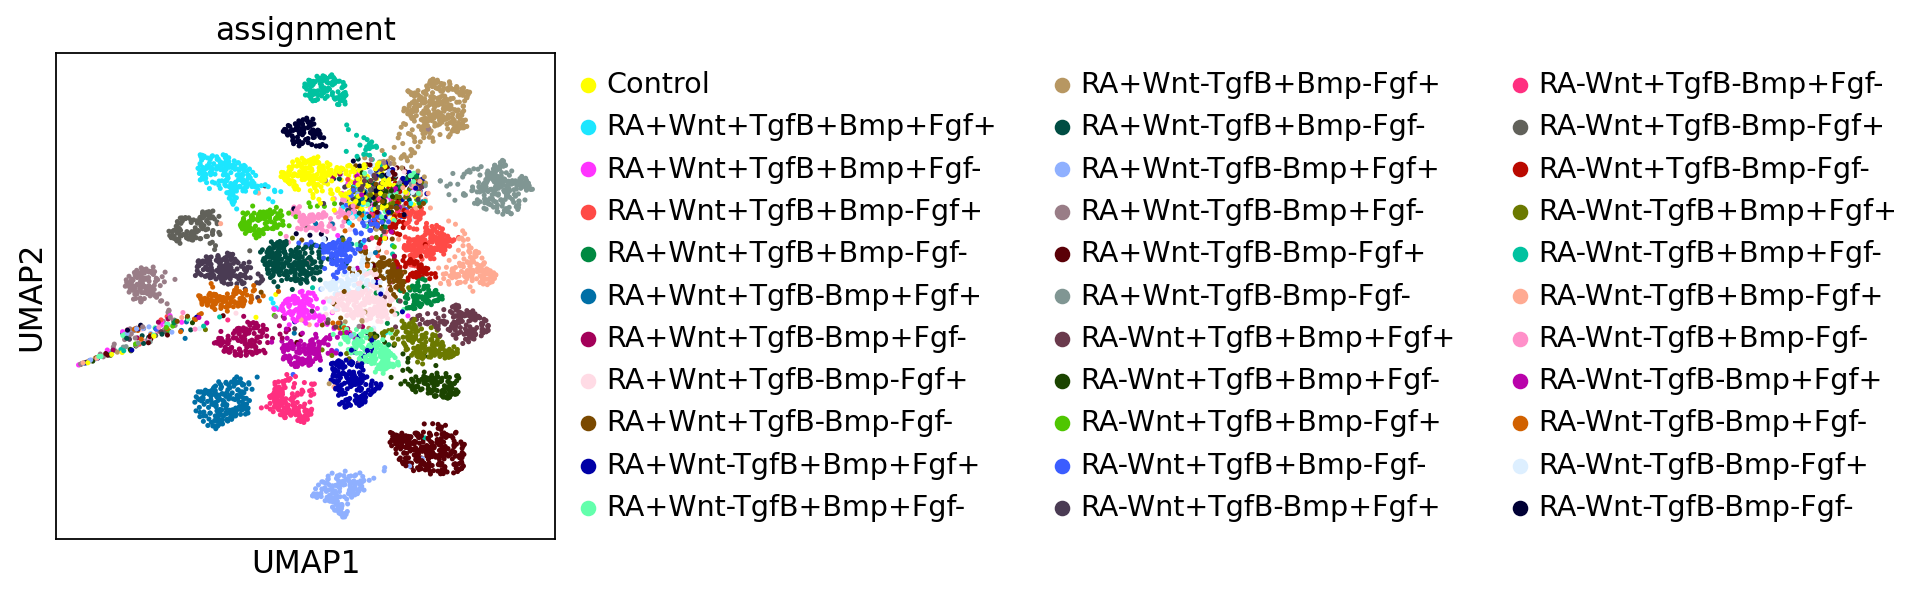

In [36]:
sc.pl.umap(m5k5_adata, color='assignment')

In [37]:
reload(dfp)

<module 'src._diffplot' from '/home/wergillius/Project/diffuse_differentiate/src/_diffplot.py'>

In [12]:
m5k5_Extrapolate_3 = dfp.extrapolate(3, config_path, 
                relative_ckpt, device=3)
deltaX_exT3 = m5k5_Extrapolate_3.X - m5k5_adata.X
trav_adata = dfp.compute_velocity(adata=adata, velocity_matrix=-1*deltaX_exT3,
                    n_neighbors = 30, n_jobs=20)
scv.pl.velocity_embedding_stream(trav_adata,
                                    color='assignment', 
                                    legend_loc='far right', 
                                    )

Lightning automatically upgraded your loaded checkpoint from v1.7.7 to v1.9.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../../../../data/diffuse_differentiate/Barcodelet/Epsilon_Linear_mesc_5layer_k=15_traverse_notime/lightning_logs/version_2/checkpoints/epoch=19-step=2920.ckpt`


loadin adata with 5745 cells, which normally takes around 0.22 mins
checkpoint finded
Equivalent_Diffuse_Sampler loaded with module Epsilon_Linear


100%|██████████| 18/18 [00:01<00:00, 13.44it/s]


Lightning automatically upgraded your loaded checkpoint from v1.7.7 to v1.9.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../../../../data/diffuse_differentiate/Barcodelet/Epsilon_Linear_mesc_5layer_k=15_traverse_notime/lightning_logs/version_2/checkpoints/epoch=19-step=2920.ckpt`


loadin adata with 5745 cells, which normally takes around 0.22 mins
checkpoint finded
Equivalent_Diffuse_Sampler loaded with module Epsilon_Linear


100%|██████████| 18/18 [00:01<00:00, 13.09it/s]


computing velocity graph (using 1/48 cores)


  0%|          | 0/5745 [00:00<?, ?cells/s]

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scvelo/core/_parallelize.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  res = np.array(res) if as_array else res


    finished (0:00:40) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


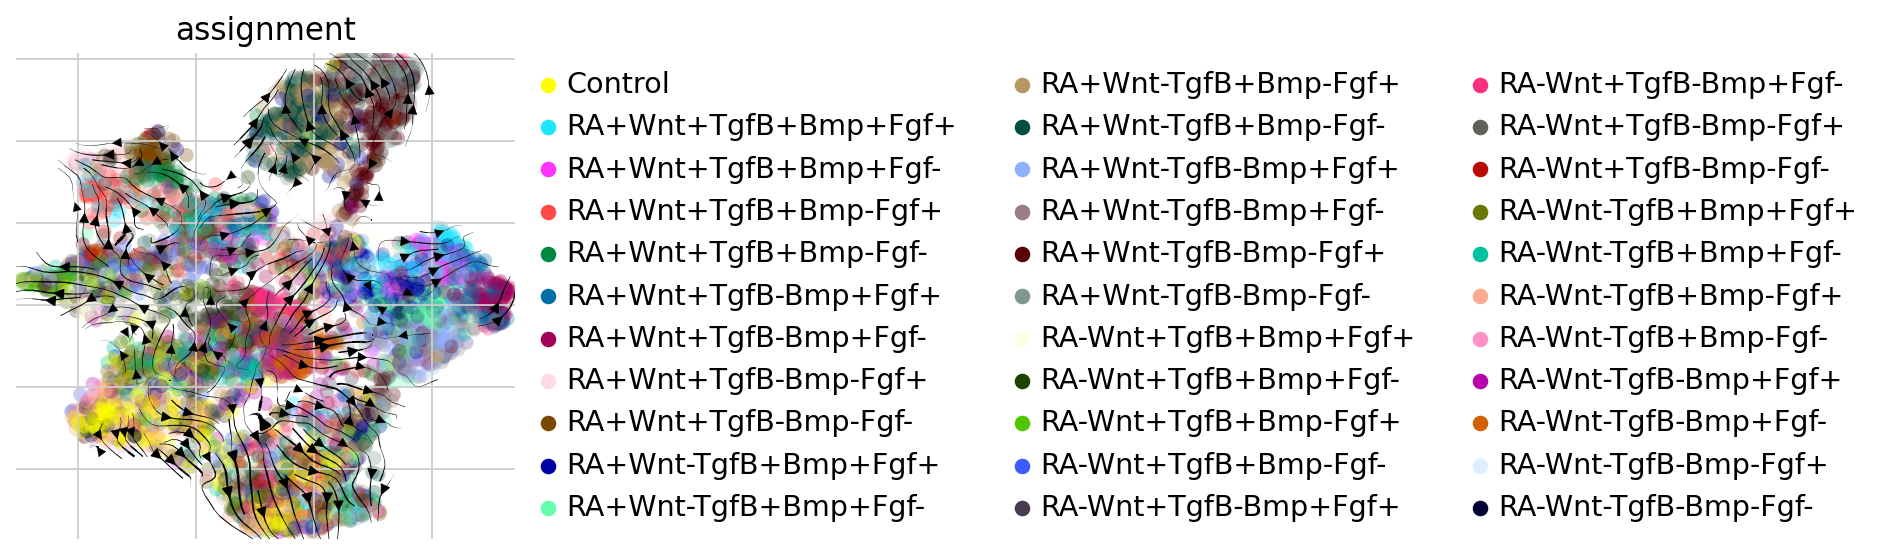

In [38]:
m5k5_Extrapolate_7 = dfp.extrapolate(7, config_path, 
                relative_ckpt, device=3)
deltaX_exT7 = m5k5_Extrapolate_7.X - m5k5_adata.X
trav_adata = dfp.compute_velocity(adata=adata, velocity_matrix=-1*deltaX_exT7,
                    n_neighbors = 30, n_jobs=20)
scv.pl.velocity_embedding_stream(trav_adata,
                                    color='assignment', 
                                    legend_loc='far right', 
                                    )

computing velocity graph (using 20/48 cores)


  0%|          | 0/5745 [00:00<?, ?cells/s]

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scvelo/core/_parallelize.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  res = np.array(res) if as_array else res


    finished (0:00:11) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


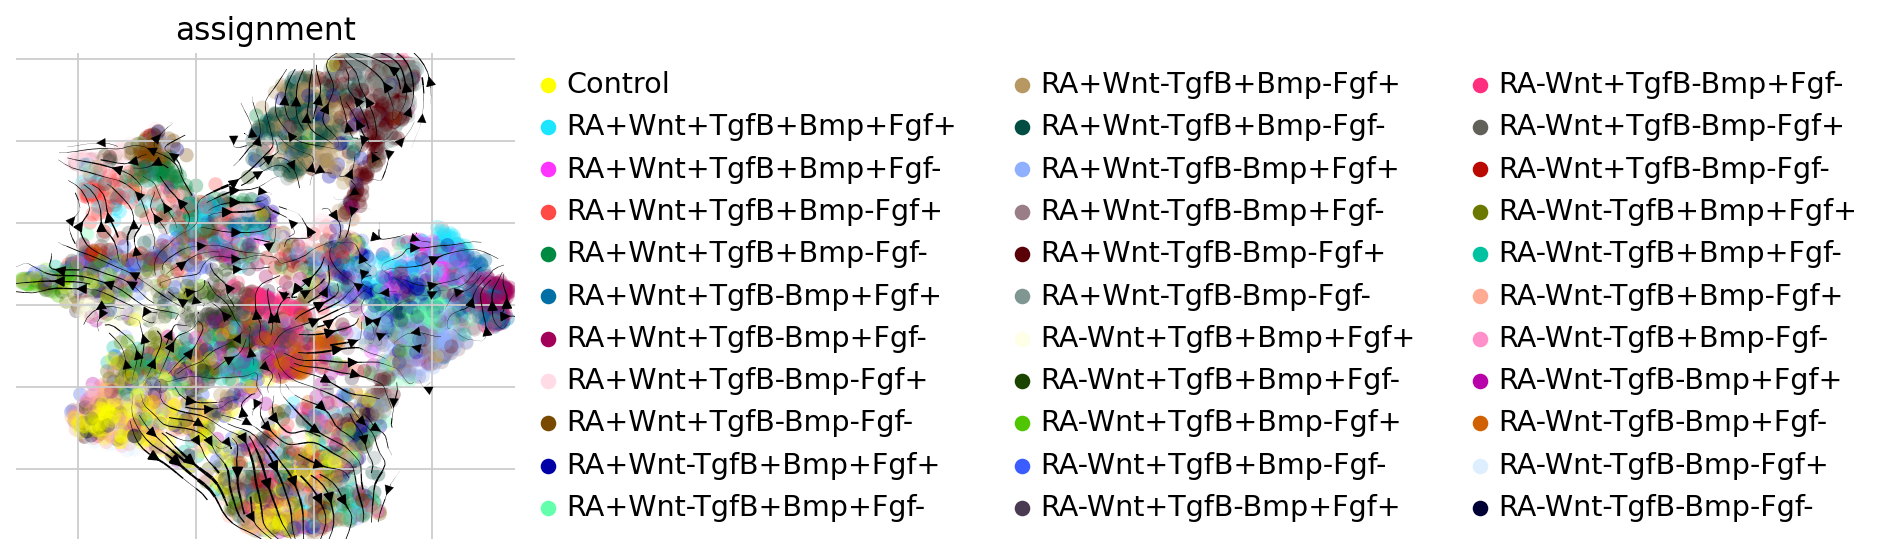

In [29]:
# sample delta x
reload(dfp)
# Delta_X = dfp.sample_Delta_X(yaml_path = config_path,
#                 sampling_repeat = 100, n_workers=20,
#                 return_repeat = True
#                     )
# Delta_X = np.squeeze(Delta_X) # [30, 5802, 1, 2000] -> [30, 5802, 2000]
trav_adata = dfp.compute_velocity(adata=adata, velocity_matrix=-1*Delta_X.mean(axis=0),
                    n_neighbors = 30, n_jobs=20)
scv.pl.velocity_embedding_stream(trav_adata,
                                    color='assignment', 
                                    legend_loc='far right', 
                                    )

In [27]:
np.save("/home/wergillius/Project/diffuse_differentiate/result/Barcodelet/Int_mes_DeltaX.npy", Delta_X)